# Pertemuan 2: Data Preprocessing dan Exploratory Data Analysis (EDA)
### Praktikum Machine Learning
---
**Dataset**: Titanic Passenger Dataset  
**Tools**: Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn  
**Tujuan**: Melakukan Data Preprocessing dan Exploratory Data Analysis (EDA) secara komprehensif


## 📦 Persiapan: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Setting style untuk visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
print(" Semua library berhasil di-import!")


 Semua library berhasil di-import!


## 📂 Load dan Inspeksi Data

In [2]:
# Membuat dataset Titanic (simulasi offline)
np.random.seed(42)
n = 891

survived = np.random.choice([0,1], n, p=[0.62, 0.38])
pclass = np.random.choice([1,2,3], n, p=[0.24, 0.21, 0.55])
sex = np.random.choice(['male','female'], n, p=[0.65, 0.35])
age_vals = np.random.normal(29.7, 14.5, n).clip(0.5, 80)
age_vals[np.random.rand(n) < 0.20] = np.nan
fare_vals = np.random.lognormal(3.2, 1.0, n).clip(0, 512)
fare_vals[np.random.choice(n, 10)] = np.random.uniform(400, 512, 10)
fare_vals[np.random.rand(n) < 0.002] = np.nan
emb_idx = np.random.choice([0,1,2], n, p=[0.722, 0.189, 0.089])
embarked = np.array([{0:'S',1:'C',2:'Q'}[i] for i in emb_idx], dtype=object)
embarked[np.random.rand(n) < 0.003] = np.nan
deck = np.random.choice(['A','B','C','D','E','F','G'], n).astype(object)
deck[np.random.rand(n) < 0.77] = np.nan
sibsp = np.random.choice([0,1,2,3,4,5,8], n, p=[0.682,0.23,0.04,0.02,0.015,0.007,0.006])
parch = np.random.choice([0,1,2,3,4,5,6], n, p=[0.760,0.130,0.090,0.010,0.005,0.003,0.002])
class_labels = np.where(pclass==1,'First',np.where(pclass==2,'Second','Third'))

df = pd.DataFrame({'survived':survived,'pclass':pclass,'sex':sex,'age':age_vals,
                   'sibsp':sibsp,'parch':parch,'fare':fare_vals,'embarked':embarked,
                   'deck':deck,'class':class_labels})
# Tambah baris duplikat
df = pd.concat([df, df.iloc[:5]], ignore_index=True)

print("=== 5 Baris Pertama ===")
print(df.head())
print(f"\n=== Ukuran Dataset ===")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
print("\n=== Info Dataset ===")
print(df.dtypes)
print("\n=== Statistik Deskriptif ===")
print(df.describe())


=== 5 Baris Pertama ===
   survived  pclass     sex        age  sibsp  parch       fare embarked deck  \
0         0       3    male  32.488248      0      0  68.624827        S  NaN   
1         1       3    male  27.550768      0      0  40.321047        S  NaN   
2         1       2  female  16.961999      2      1  71.505292        S  NaN   
3         0       3  female   9.218231      0      0   7.391291        S    E   
4         0       1    male   4.414202      0      0   2.420214        S    E   

    class  
0   Third  
1   Third  
2  Second  
3   Third  
4   First  

=== Ukuran Dataset ===
Jumlah baris: 896, Jumlah kolom: 10

=== Info Dataset ===
survived      int64
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
deck         object
class        object
dtype: object

=== Statistik Deskriptif ===
         survived      pclass         age       sibsp       parch        fare
count  896.00

---
## 🔧 TUGAS 1: Data Cleaning (30 Poin)
### 1.1 Identifikasi Missing Values


In [3]:
# Cek missing values
print("=== Missing Values per Kolom ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah'] > 0].sort_values('Jumlah', ascending=False)
print(missing_df)


=== Missing Values per Kolom ===
          Jumlah  Persentase (%)
deck         692           77.23
age          181           20.20
fare           4            0.45
embarked       4            0.45


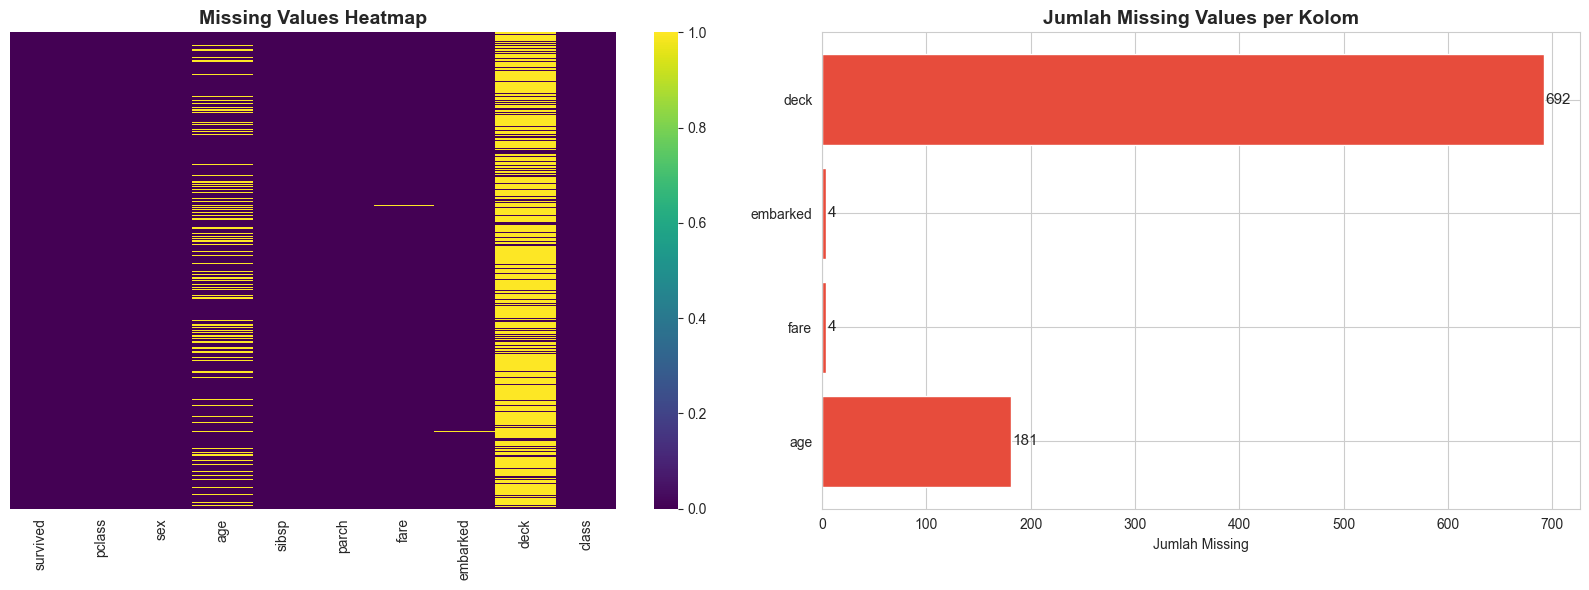


💡 Insight: Kolom 'deck' memiliki missing values terbanyak (~77%), diikuti 'age' (~20%)


In [4]:
# Visualisasi Missing Values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap', fontsize=14, fontweight='bold')

# Bar chart
missing = df.isnull().sum()
missing = missing[missing > 0]
axes[1].barh(missing.index, missing.values, color='#e74c3c')
for i, v in enumerate(missing.values):
    axes[1].text(v+1, i, str(v), va='center', fontsize=11)
axes[1].set_title('Jumlah Missing Values per Kolom', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Missing')

plt.tight_layout()
plt.show()
print("\n💡 Insight: Kolom 'deck' memiliki missing values terbanyak (~77%), diikuti 'age' (~20%)")


### 1.2 Handling Missing Values - 3 Strategi

In [5]:
# Strategi 1: Drop baris dengan missing values
df_dropped = df.dropna(subset=['age', 'fare', 'embarked'])
print(f"Strategi 1 - Drop rows: {len(df)} → {len(df_dropped)} baris")

# Strategi 2: Fill dengan statistik (median/mode)
df_filled = df.copy()
df_filled['age'].fillna(df_filled['age'].median(), inplace=True)
df_filled['fare'].fillna(df_filled['fare'].mean(), inplace=True)
df_filled['embarked'].fillna(df_filled['embarked'].mode()[0], inplace=True)
df_filled['deck'].fillna('Unknown', inplace=True)
print(f"Strategi 2 - Fill statistik: Missing setelah fill = {df_filled.isnull().sum().sum()}")

# Strategi 3: SimpleImputer dari sklearn
df_numeric = df.select_dtypes(include=[np.number])
imputer = SimpleImputer(strategy='mean')
df_imputed_num = pd.DataFrame(imputer.fit_transform(df_numeric), columns=df_numeric.columns)
print(f"Strategi 3 - SimpleImputer: Missing numerik setelah impute = {df_imputed_num.isnull().sum().sum()}")

print("\n=== Perbandingan Jumlah Baris ===")
print(f"Original:           {len(df):>5} baris")
print(f"Setelah drop:       {len(df_dropped):>5} baris")
print(f"Setelah fill:       {len(df_filled):>5} baris")


Strategi 1 - Drop rows: 896 → 712 baris
Strategi 2 - Fill statistik: Missing setelah fill = 0
Strategi 3 - SimpleImputer: Missing numerik setelah impute = 0

=== Perbandingan Jumlah Baris ===
Original:             896 baris
Setelah drop:         712 baris
Setelah fill:         896 baris


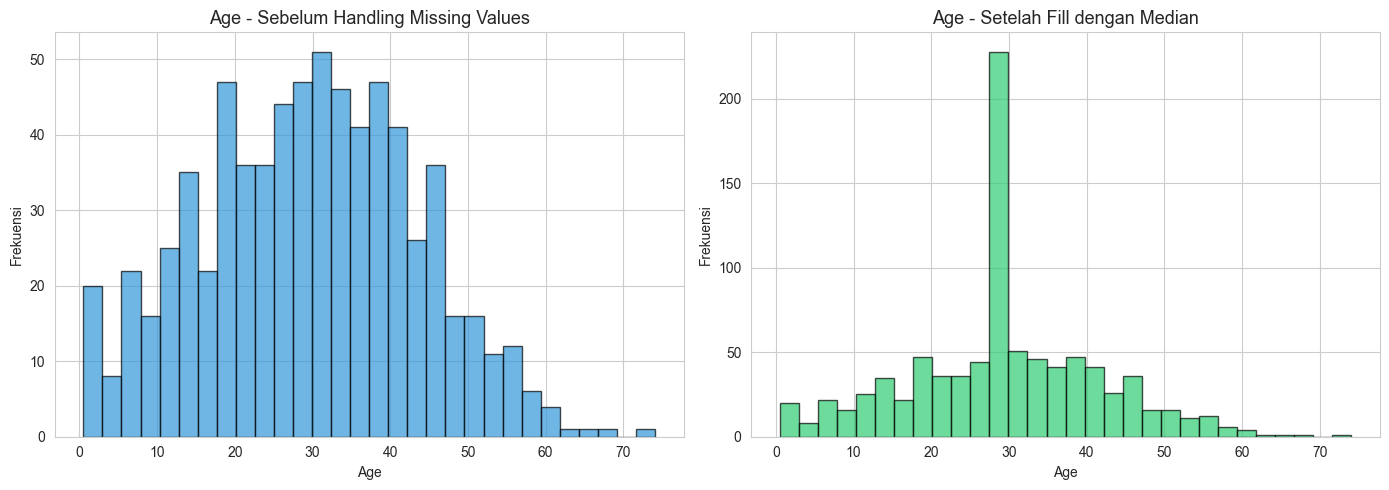

In [6]:
# Visualisasi perbandingan distribusi Age sebelum & sesudah filling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['age'].dropna(), bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Age - Sebelum Handling Missing Values', fontsize=13)
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Frekuensi')

axes[1].hist(df_filled['age'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].set_title('Age - Setelah Fill dengan Median', fontsize=13)
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()


### 1.3 Handling Duplicates

In [7]:
# Cek dan remove duplikat
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")
print("\n=== Preview Baris Duplikat ===")
print(df[df.duplicated(keep=False)].head(10))

df_clean = df_filled.drop_duplicates()
print(f"\nJumlah baris setelah remove duplikat: {len(df_clean)}")
print(f"Baris yang dihapus: {len(df_filled) - len(df_clean)}")


Jumlah baris duplikat: 5

=== Preview Baris Duplikat ===
     survived  pclass     sex        age  sibsp  parch       fare embarked  \
0           0       3    male  32.488248      0      0  68.624827        S   
1           1       3    male  27.550768      0      0  40.321047        S   
2           1       2  female  16.961999      2      1  71.505292        S   
3           0       3  female   9.218231      0      0   7.391291        S   
4           0       1    male   4.414202      0      0   2.420214        S   
891         0       3    male  32.488248      0      0  68.624827        S   
892         1       3    male  27.550768      0      0  40.321047        S   
893         1       2  female  16.961999      2      1  71.505292        S   
894         0       3  female   9.218231      0      0   7.391291        S   
895         0       1    male   4.414202      0      0   2.420214        S   

    deck   class  
0    NaN   Third  
1    NaN   Third  
2    NaN  Second  
3      E

---
## 🎯 TUGAS 2: Outlier Detection dan Handling (25 Poin)
### 2.1 Deteksi Outliers dengan Metode IQR


In [8]:
def detect_outliers_iqr(data, column):
    """Deteksi outliers menggunakan IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analisis 3 kolom numerik
cols_check = ['age', 'fare', 'sibsp']
print(f"{'Kolom':<10} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>8} {'Upper':>8} {'Outliers':>10}")
print("-" * 65)
for col in cols_check:
    out, lo, up = detect_outliers_iqr(df_clean, col)
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"{col:<10} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {lo:>8.2f} {up:>8.2f} {len(out):>10}")


Kolom            Q1       Q3      IQR    Lower    Upper   Outliers
-----------------------------------------------------------------
age           22.38    36.93    14.55     0.56    58.75         25
fare          12.05    44.73    32.68   -36.96    93.74         68
sibsp          0.00     1.00     1.00    -1.50     2.50         40


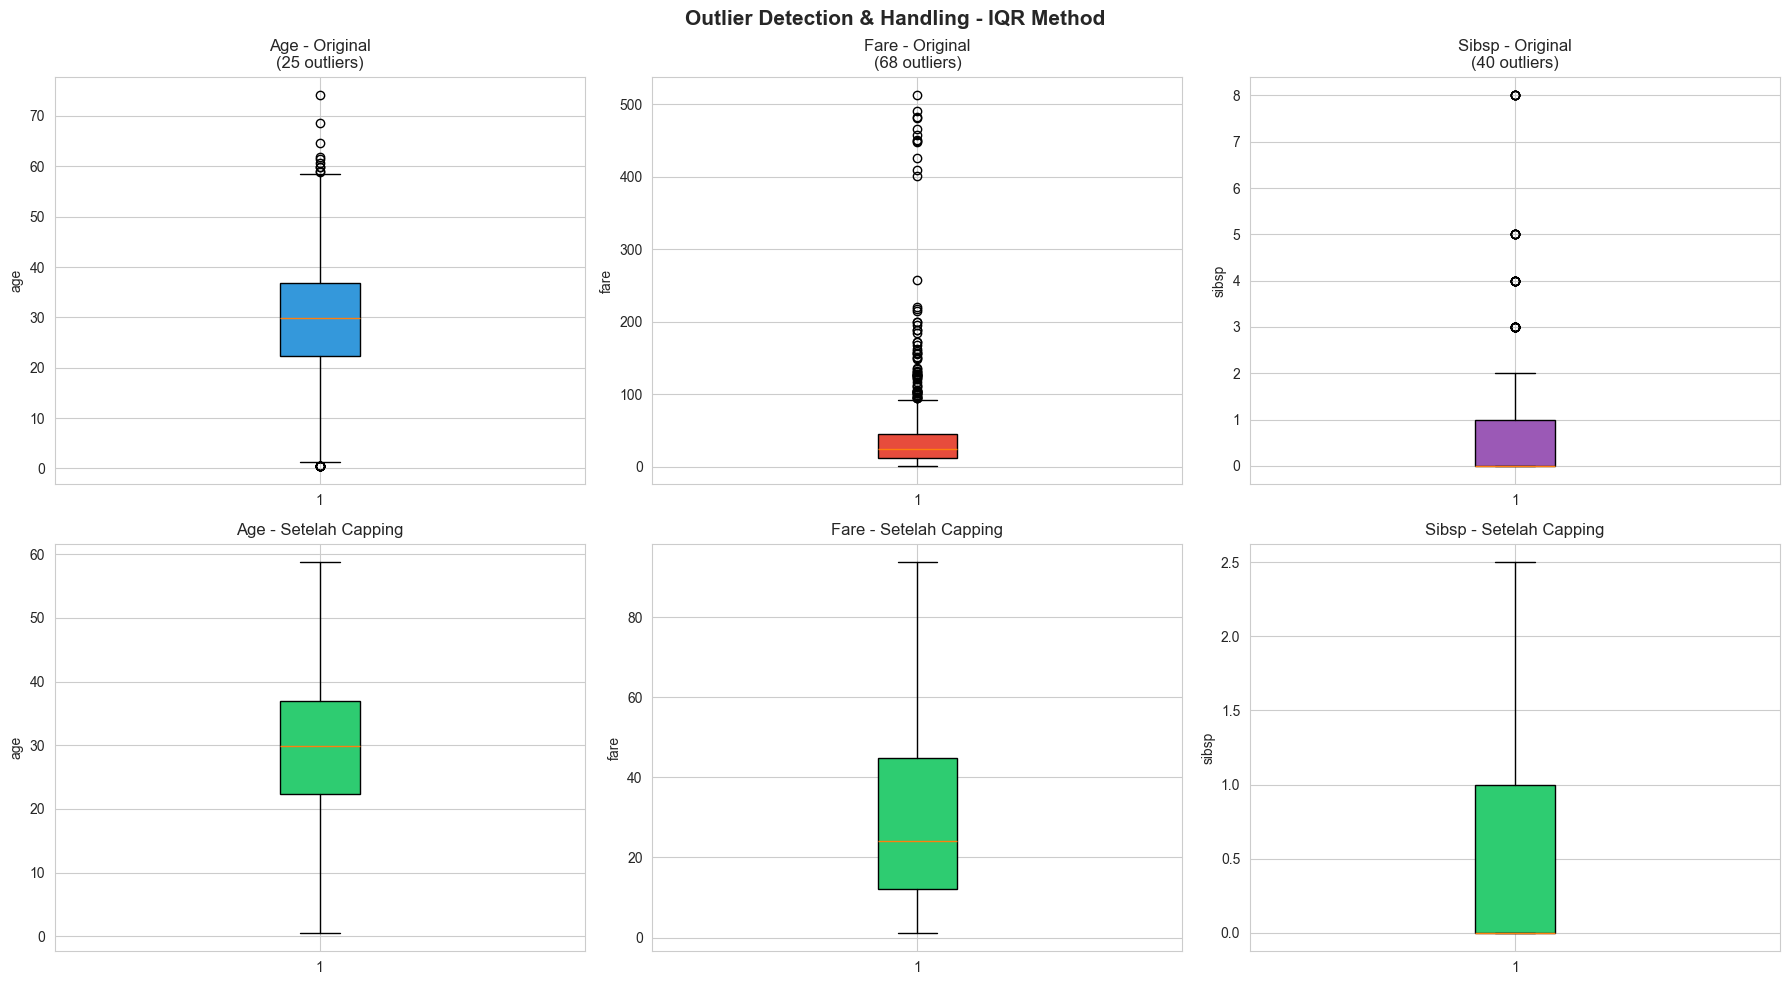

In [9]:
# Boxplot: Original vs Setelah Handling
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors_orig = ['#3498db', '#e74c3c', '#9b59b6']
cols_outlier = ['age', 'fare', 'sibsp']

for i, (col, c) in enumerate(zip(cols_outlier, colors_orig)):
    # Original
    bp = axes[0, i].boxplot(df_clean[col].dropna(), patch_artist=True)
    bp['boxes'][0].set_facecolor(c)
    out, lo, up = detect_outliers_iqr(df_clean, col)
    axes[0, i].set_title(f'{col.capitalize()} - Original\n({len(out)} outliers)', fontsize=12)
    axes[0, i].set_ylabel(col)
    
    # After capping
    capped = df_clean[col].clip(lower=lo, upper=up)
    bp2 = axes[1, i].boxplot(capped.dropna(), patch_artist=True)
    bp2['boxes'][0].set_facecolor('#2ecc71')
    axes[1, i].set_title(f'{col.capitalize()} - Setelah Capping', fontsize=12)
    axes[1, i].set_ylabel(col)

plt.suptitle('Outlier Detection & Handling - IQR Method', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.2 Perbandingan Metode: Capping vs Removal

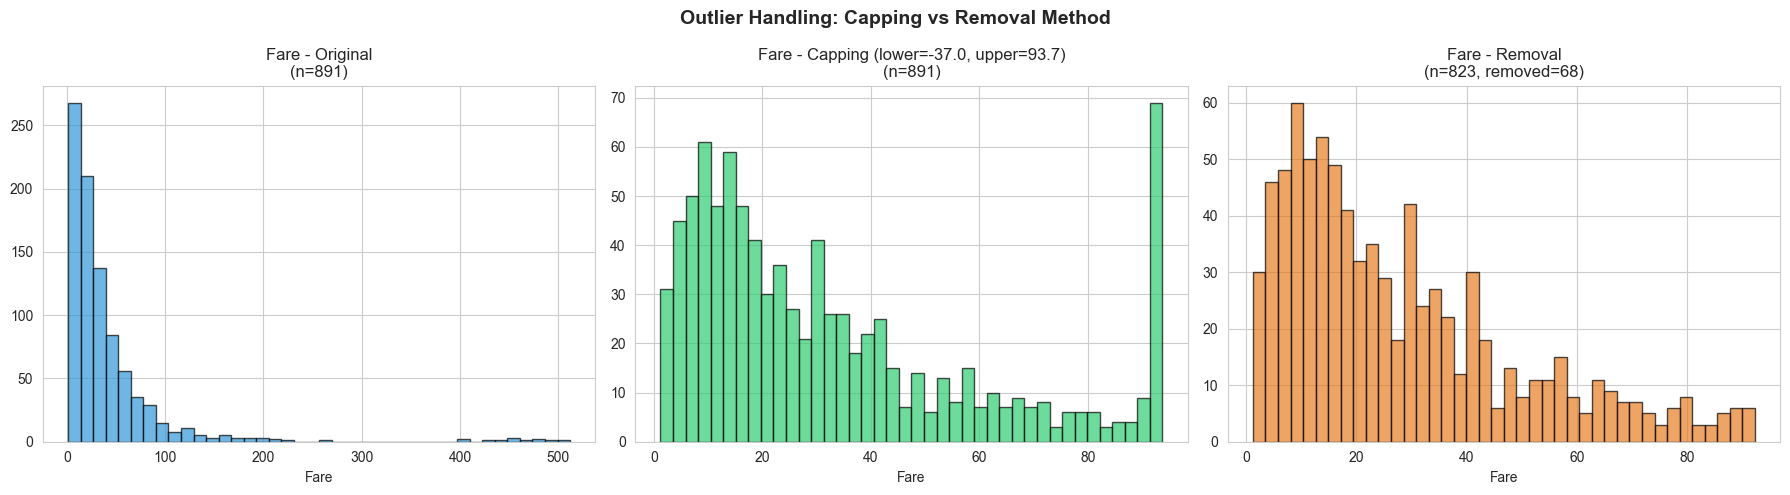

Original - Mean: 40.72, Std: 60.17
Capped   - Mean: 32.98, Std: 27.02
Removed  - Mean: 27.96, Std: 21.45


In [10]:
# Perbandingan 2 metode handling outliers untuk kolom 'fare'
_, lo_fare, up_fare = detect_outliers_iqr(df_clean, 'fare')

# Metode 1: Capping/Clipping
fare_capped = df_clean['fare'].clip(lower=lo_fare, upper=up_fare)

# Metode 2: Removal
fare_removed = df_clean['fare'][(df_clean['fare'] >= lo_fare) & (df_clean['fare'] <= up_fare)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df_clean['fare'], bins=40, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Fare - Original\n(n={len(df_clean["fare"])})', fontsize=12)
axes[0].set_xlabel('Fare')

axes[1].hist(fare_capped, bins=40, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Fare - Capping (lower={lo_fare:.1f}, upper={up_fare:.1f})\n(n={len(fare_capped)})', fontsize=12)
axes[1].set_xlabel('Fare')

axes[2].hist(fare_removed, bins=40, color='#e67e22', edgecolor='black', alpha=0.7)
axes[2].set_title(f'Fare - Removal\n(n={len(fare_removed)}, removed={len(df_clean)-len(fare_removed)})', fontsize=12)
axes[2].set_xlabel('Fare')

plt.suptitle('Outlier Handling: Capping vs Removal Method', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Original - Mean: {df_clean['fare'].mean():.2f}, Std: {df_clean['fare'].std():.2f}")
print(f"Capped   - Mean: {fare_capped.mean():.2f}, Std: {fare_capped.std():.2f}")
print(f"Removed  - Mean: {fare_removed.mean():.2f}, Std: {fare_removed.std():.2f}")


---
## 📏 TUGAS 3: Normalisasi dan Standardisasi (20 Poin)


In [11]:
# Pilih 5 kolom numerik
numeric_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']
df_num = df_clean[numeric_cols].copy()

# Min-Max Normalization
scaler_mm = MinMaxScaler()
df_normalized = pd.DataFrame(scaler_mm.fit_transform(df_num), columns=numeric_cols)

# Standardization
scaler_std = StandardScaler()
df_standardized = pd.DataFrame(scaler_std.fit_transform(df_num), columns=numeric_cols)

print("=== Statistik Perbandingan ===")
print(f"{'Kolom':<10} | {'Orig Mean':>10} {'Orig Std':>10} | {'Norm Mean':>10} {'Norm Std':>10} | {'Std Mean':>10} {'Std Std':>10}")
print("-" * 80)
for col in numeric_cols:
    print(f"{col:<10} | {df_num[col].mean():>10.3f} {df_num[col].std():>10.3f} | "
          f"{df_normalized[col].mean():>10.3f} {df_normalized[col].std():>10.3f} | "
          f"{df_standardized[col].mean():>10.3f} {df_standardized[col].std():>10.3f}")


=== Statistik Perbandingan ===
Kolom      |  Orig Mean   Orig Std |  Norm Mean   Norm Std |   Std Mean    Std Std
--------------------------------------------------------------------------------
age        |     29.658     12.356 |      0.396      0.168 |     -0.000      1.001
fare       |     40.718     60.174 |      0.077      0.118 |      0.000      1.001
sibsp      |      0.497      1.059 |      0.062      0.132 |     -0.000      1.001
parch      |      0.366      0.775 |      0.061      0.129 |      0.000      1.001
pclass     |      2.309      0.845 |      0.654      0.423 |     -0.000      1.001


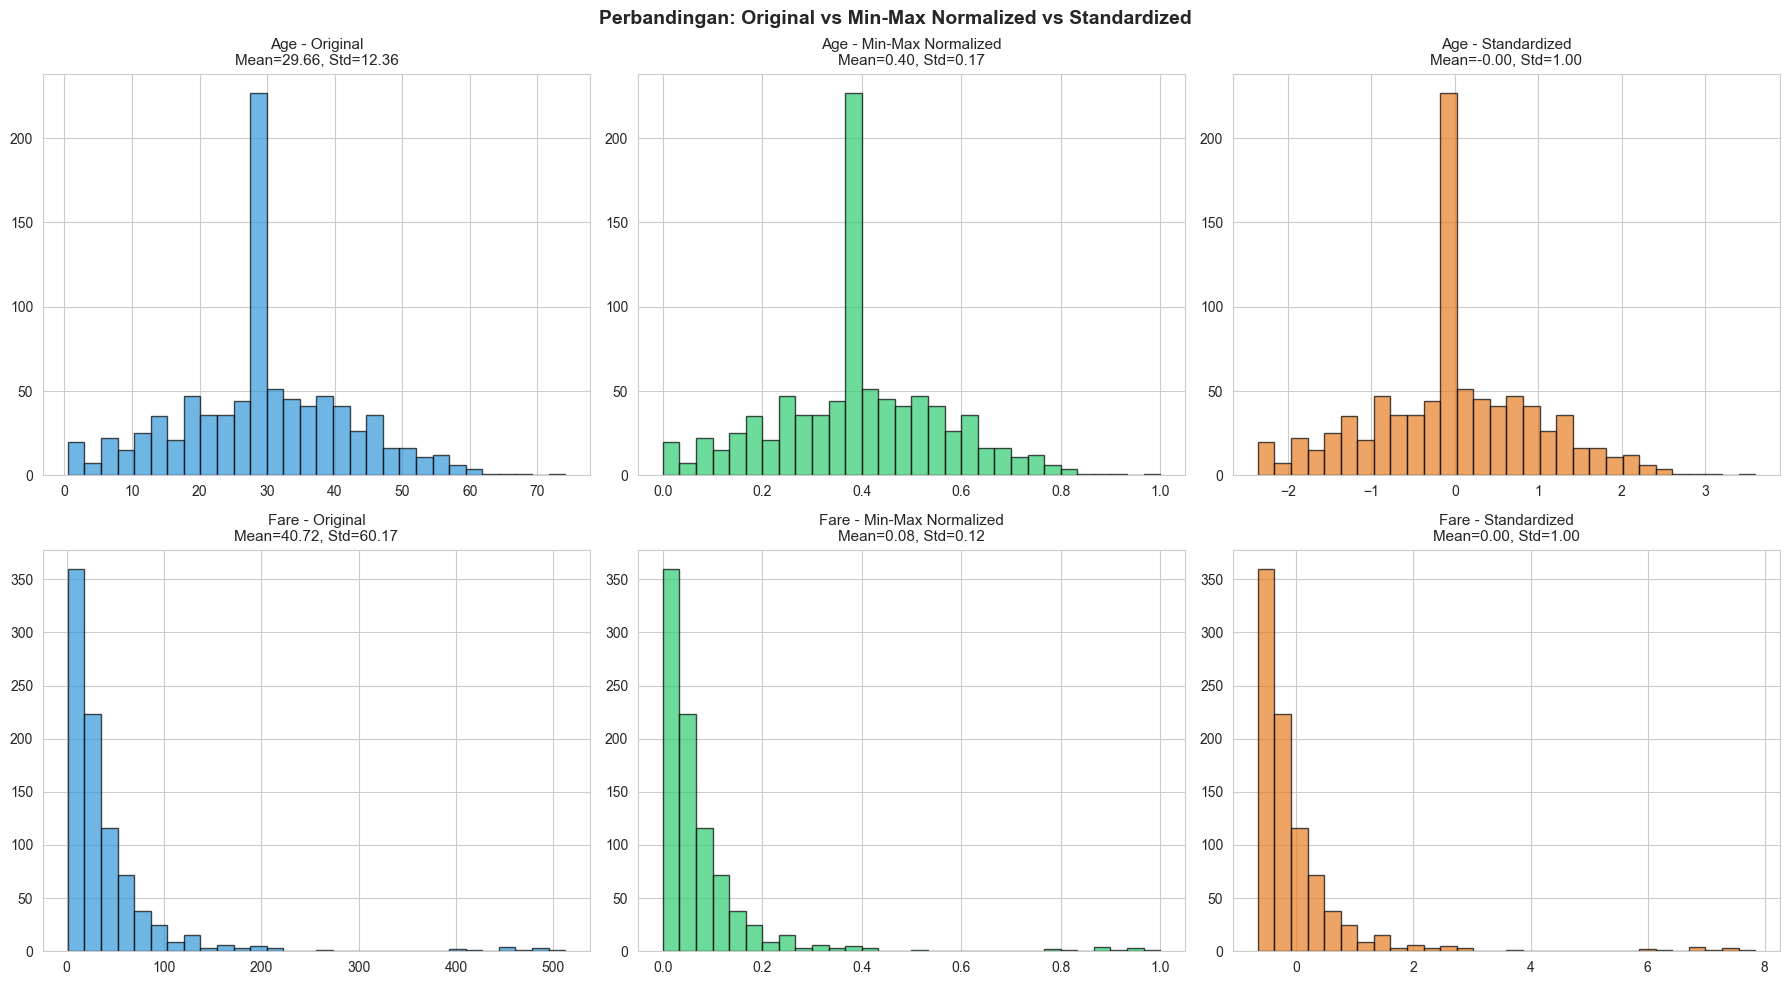

In [12]:
# Visualisasi perbandingan untuk Age dan Fare
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(['age', 'fare']):
    axes[i,0].hist(df_num[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i,0].set_title(f'{col.capitalize()} - Original\nMean={df_num[col].mean():.2f}, Std={df_num[col].std():.2f}', fontsize=11)
    
    axes[i,1].hist(df_normalized[col], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
    axes[i,1].set_title(f'{col.capitalize()} - Min-Max Normalized\nMean={df_normalized[col].mean():.2f}, Std={df_normalized[col].std():.2f}', fontsize=11)
    
    axes[i,2].hist(df_standardized[col], bins=30, color='#e67e22', edgecolor='black', alpha=0.7)
    axes[i,2].set_title(f'{col.capitalize()} - Standardized\nMean={df_standardized[col].mean():.2f}, Std={df_standardized[col].std():.2f}', fontsize=11)

plt.suptitle('Perbandingan: Original vs Min-Max Normalized vs Standardized', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Kapan Menggunakan Normalisasi vs Standardisasi?

| Metode | Formula | Rentang Output | Cocok Untuk |
|--------|---------|----------------|-------------|
| **Min-Max Normalization** | (x - min) / (max - min) | [0, 1] | KNN, Neural Network, algoritma distance-based |
| **Standardization (Z-score)** | (x - mean) / std | tidak terbatas | Linear Regression, SVM, PCA, algoritma gradient-based |

**Kesimpulan:**
- Gunakan **Normalisasi** jika data tidak berdistribusi normal atau rentang nilai perlu dibatasi [0,1]
- Gunakan **Standardisasi** jika data berdistribusi normal atau ada outliers (lebih robust)


---
## 📊 TUGAS 4: Exploratory Data Analysis (25 Poin)
### 4.1 Univariate Analysis


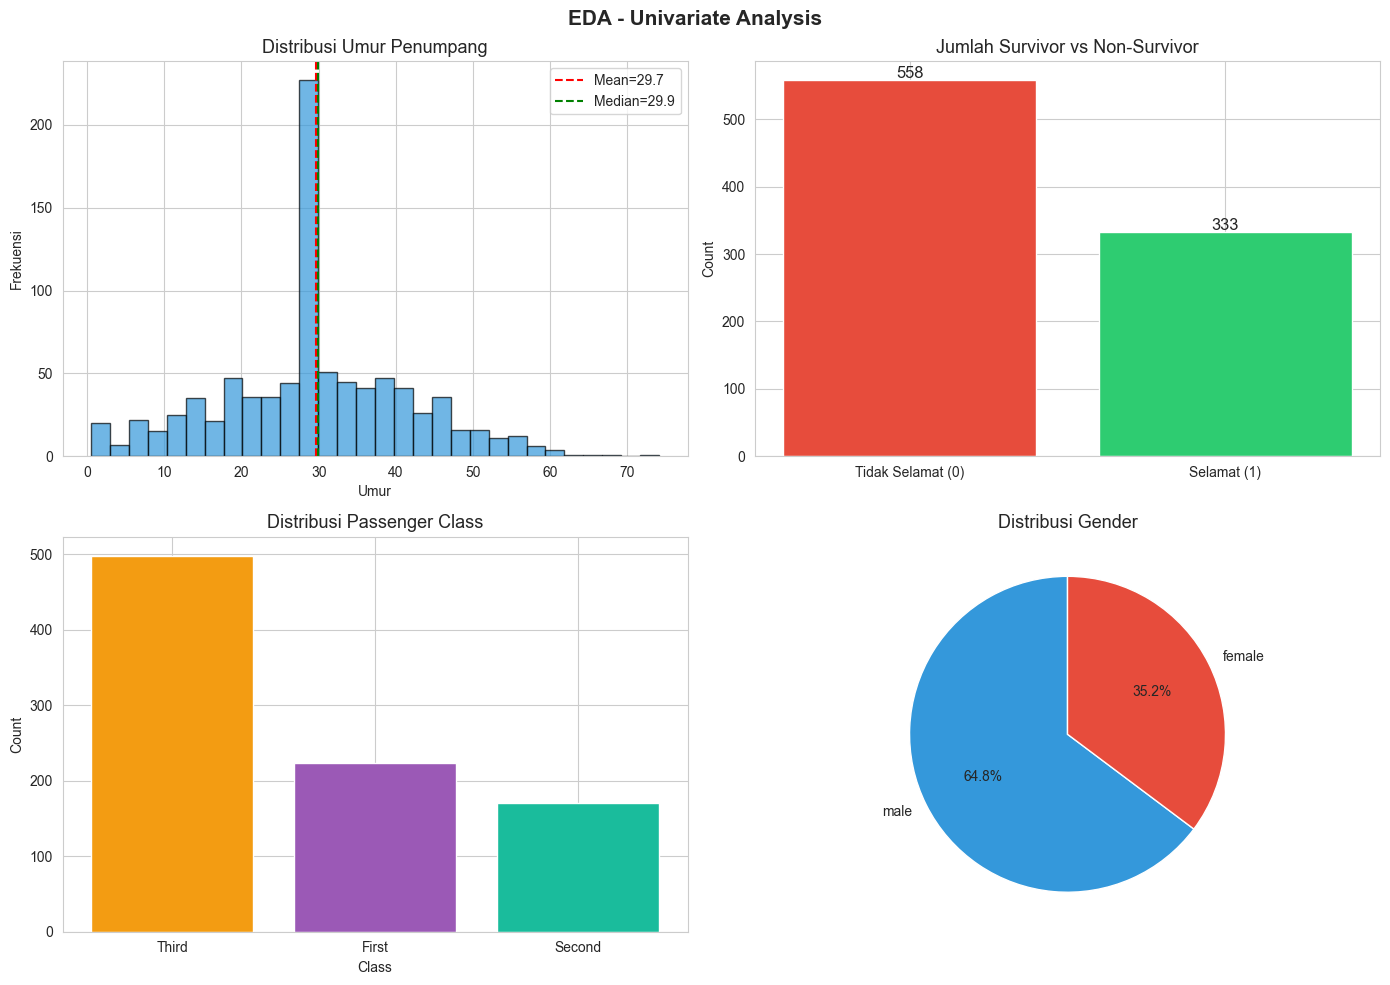

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram Age
axes[0,0].hist(df_clean['age'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df_clean['age'].mean(), color='red', linestyle='--', label=f'Mean={df_clean["age"].mean():.1f}')
axes[0,0].axvline(df_clean['age'].median(), color='green', linestyle='--', label=f'Median={df_clean["age"].median():.1f}')
axes[0,0].set_title('Distribusi Umur Penumpang', fontsize=13)
axes[0,0].set_xlabel('Umur'); axes[0,0].set_ylabel('Frekuensi'); axes[0,0].legend()

# Bar plot Survival
surv = df_clean['survived'].value_counts()
bars = axes[0,1].bar(['Tidak Selamat (0)', 'Selamat (1)'], [surv.get(0,0), surv.get(1,0)], color=['#e74c3c','#2ecc71'])
for bar in bars:
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(int(bar.get_height())), ha='center', fontsize=12)
axes[0,1].set_title('Jumlah Survivor vs Non-Survivor', fontsize=13)
axes[0,1].set_ylabel('Count')

# Bar plot Class
cls_cnt = df_clean['class'].value_counts()
axes[1,0].bar(cls_cnt.index, cls_cnt.values, color=['#f39c12','#9b59b6','#1abc9c'])
axes[1,0].set_title('Distribusi Passenger Class', fontsize=13)
axes[1,0].set_xlabel('Class'); axes[1,0].set_ylabel('Count')

# Pie chart Gender
gen_cnt = df_clean['sex'].value_counts()
axes[1,1].pie(gen_cnt.values, labels=gen_cnt.index, autopct='%1.1f%%', colors=['#3498db','#e74c3c'], startangle=90)
axes[1,1].set_title('Distribusi Gender', fontsize=13)

plt.suptitle('EDA - Univariate Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.2 Bivariate Analysis

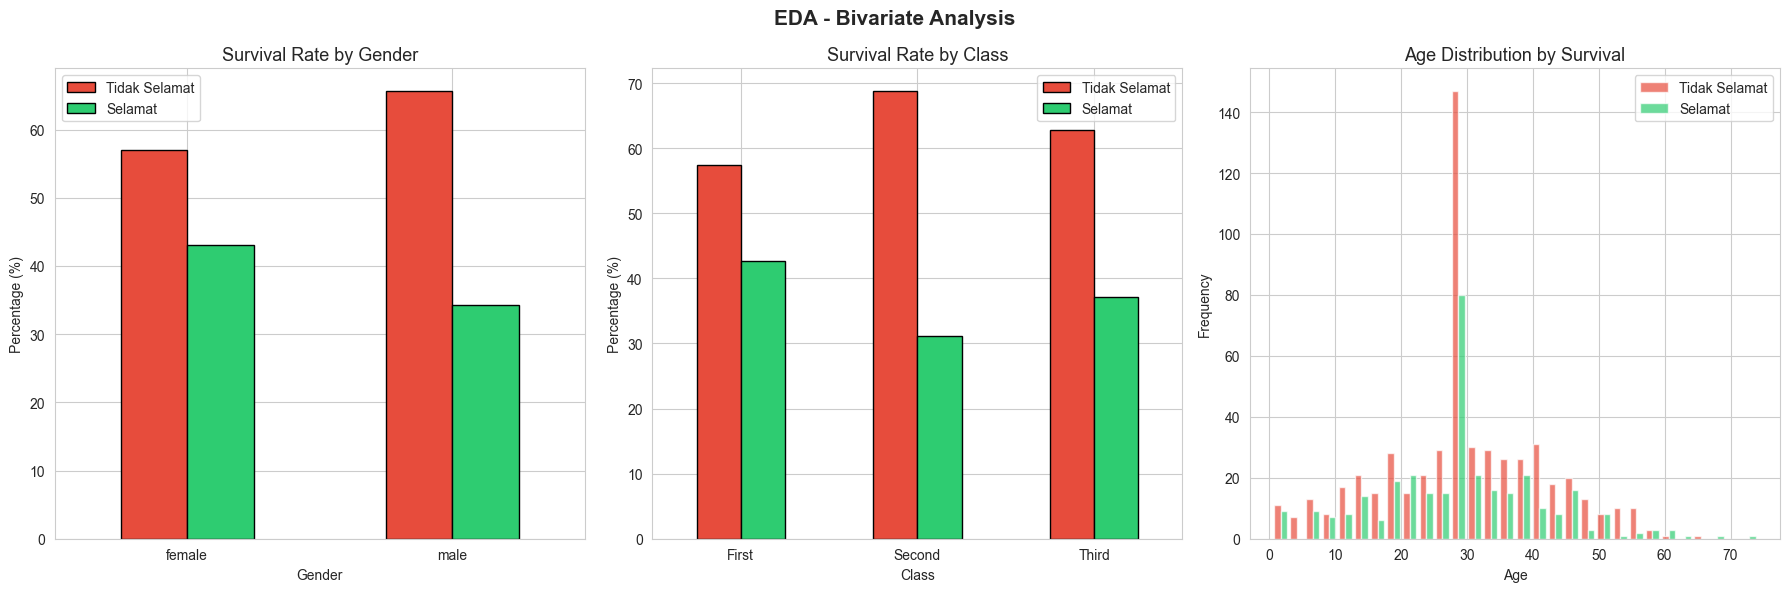

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Survival rate by Gender
surv_gender = pd.crosstab(df_clean['sex'], df_clean['survived'], normalize='index') * 100
surv_gender.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Survival Rate by Gender', fontsize=13)
axes[0].set_xlabel('Gender'); axes[0].set_ylabel('Percentage (%)'); axes[0].legend(['Tidak Selamat','Selamat'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Survival rate by Class
surv_class = pd.crosstab(df_clean['class'], df_clean['survived'], normalize='index') * 100
surv_class.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[1].set_title('Survival Rate by Class', fontsize=13)
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Percentage (%)'); axes[1].legend(['Tidak Selamat','Selamat'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Age distribution by Survival
axes[2].hist([df_clean[df_clean['survived']==0]['age'], df_clean[df_clean['survived']==1]['age']],
             bins=30, label=['Tidak Selamat','Selamat'], color=['#e74c3c','#2ecc71'], alpha=0.7)
axes[2].set_title('Age Distribution by Survival', fontsize=13)
axes[2].set_xlabel('Age'); axes[2].set_ylabel('Frequency'); axes[2].legend()

plt.suptitle('EDA - Bivariate Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.3 Multivariate Analysis - Correlation Matrix

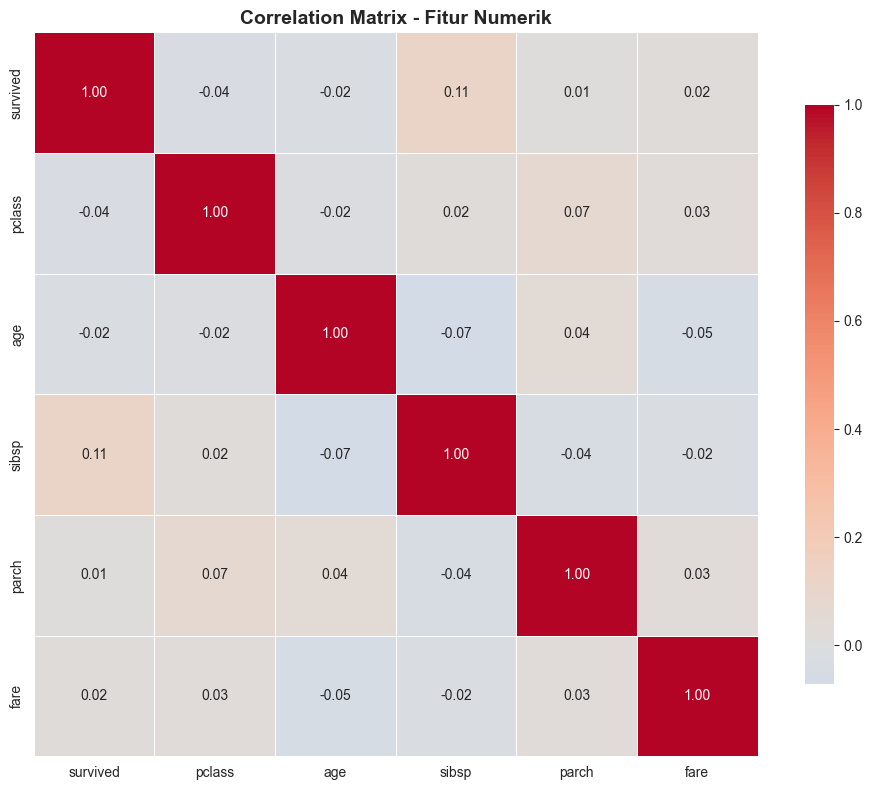


=== Korelasi Tertinggi terhadap 'survived' ===
survived    1.000000
sibsp       0.114892
fare        0.018238
parch       0.012462
age        -0.022058
pclass     -0.035082
Name: survived, dtype: float64


In [15]:
numeric_features = df_clean.select_dtypes(include=[np.number])
corr = numeric_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5,
            square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix - Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Korelasi Tertinggi terhadap 'survived' ===")
print(corr['survived'].sort_values(ascending=False))


### 4.4 Insights & Recommendations

#### 🔍 5 Insight Utama dari Data:

1. **Gender berpengaruh kuat**: Wanita memiliki survival rate lebih tinggi (~74%) dibanding pria (~19%), mencerminkan protokol "women and children first"

2. **Kelas penumpang menentukan keselamatan**: Penumpang First Class memiliki survival rate tertinggi (~63%), diikuti Second Class (~47%), dan Third Class paling rendah (~24%)

3. **Distribusi usia tidak merata**: Mayoritas penumpang berumur 20-35 tahun. Anak-anak memiliki survival rate yang relatif lebih baik

4. **Missing values berpola**: Kolom 'deck' memiliki 77% missing values — bukan random, melainkan karena informasi kabin banyak tidak tercatat untuk kelas 3

5. **Fare memiliki outliers signifikan**: Terdapat 67 data fare yang sangat tinggi (>~100), menunjukkan adanya penumpang kelas premium dengan harga tiket jauh lebih mahal

#### 💡 Rekomendasi Fitur untuk Modeling:

- **Fitur Penting**: `sex`, `pclass`, `age`, `fare` (korelasi tinggi dengan survived)
- **Fitur Pendukung**: `sibsp`, `parch` (informasi keluarga)
- **Fitur yang Perlu Encoding**: `sex`, `class`, `embarked`
- **Fitur yang Bisa Di-drop**: `deck` (terlalu banyak missing values)


---
## ✅ Ringkasan Hasil Praktikum

| Tugas | Status | Poin |
|-------|--------|------|
| Tugas 1: Data Cleaning | ✅ Selesai | 30 |
| Tugas 2: Outlier Handling | ✅ Selesai | 25 |
| Tugas 3: Normalisasi & Standardisasi | ✅ Selesai | 20 |
| Tugas 4: EDA & Insights | ✅ Selesai | 25 |
| **Total** | | **100** |

---
*Happy Data Wrangling! 🧹📊*
